In [1]:
# import libaries

import csv
import numpy as np
import pandas as pd
import glob
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pandas as pd
from operator import itemgetter
import seaborn as sns
from tqdm import tqdm
import math
import pickle
from scipy import stats

import numpyro
from jax import random, vmap

import os
#os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
#os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='0.5'

from numpyro.diagnostics import hpdi
import numpyro.distributions as dist
from numpyro import handlers
from numpyro.infer import MCMC, NUTS
from numpyro.infer import initialization
import jax.numpy, jax.scipy
import scipy.stats
from numpyro.infer.reparam import TransformReparam
import Bio
from scipy.special import softmax

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

gpu
Fri Apr 11 13:07:58 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-PCIE-16GB            On | 00000000:C1:00.0 Off |                    0 |
| N/A   31C    P0               35W / 250W|   4110MiB / 16384MiB |      2%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+---------------------

In [2]:
def additive_model(df_dg,aa_len):
    # aa_len: number of amino acids (usually 20)
    # df_dg: datafame including aa1, aa2 (index), and raw deltaG values 
    
    # first/second_aa_effect: coefficients representing first/second amino acid effects [aa_len]
    first_aa_effect = numpyro.sample("first_aa_effect", dist.Normal(np.resize(0.1, (aa_len)), 3))
    second_aa_effect = numpyro.sample("second_aa_effect", dist.Normal(np.resize(0.1, (aa_len)), 3))

    # list of index of 1st aa, index of 2nd aa, [length of df_dg]
    first_aa_index = list(df_dg['aa1'])
    second_aa_index = list(df_dg['aa2'])
    
    # list of observed deltaG [length of df_dg]
    obs_dg_list = jax.numpy.array(df_dg['dG'])
    
    # pred_aa_dg_list: predicted deltaG using aa_len x2 (usually 40 = 20x2) coefficients, then clip the data bewteen -1 to 5
    pred_aa_dg_list = jax.numpy.array([first_aa_effect[index] for index in first_aa_index])+jax.numpy.array([second_aa_effect[index] for index in second_aa_index])
    clipped_pred_aa_dg_list =  jax.numpy.clip(pred_aa_dg_list,-1,5)
    
    # sigma: uncertainty of the data
    sigma = numpyro.sample("sigma", dist.Exponential(1))   
    
    # fitting coefficients by assuming predicted deltaG matches observed dG
    numpyro.sample("obs_dg",dist.TransformedDistribution(dist.Normal(0, 1), dist.transforms.AffineTransform(clipped_pred_aa_dg_list,sigma)), obs = obs_dg_list)

In [3]:
df_mock_data = pd.DataFrame()
df_mock_data['aa1'] = [1,1,1,1,2,2,2,2,3,3,3,3,4,4,4,4]
df_mock_data['aa2'] = [1,2,3,4,1,2,3,4,1,2,3,4,1,2,3,4]
df_mock_data['dG']  = [0,1,5,2,0,2,3,4,2,5,4,5,3,4,5,0]
df_mock_data

,aa1,aa2,dG
0,1,1,0
1,1,2,1
2,1,3,5
3,1,4,2
4,2,1,0
5,2,2,2
6,2,3,3
7,2,4,4
8,3,1,2
9,3,2,5


In [4]:
rng_key = random.PRNGKey(1)
rng_key, rng_key_ = random.split(rng_key)

kernel = NUTS(additive_model, init_strategy=initialization.init_to_feasible())
mcmc = MCMC(kernel, num_warmup=10, num_samples=5, num_chains=1)


mcmc.run(rng_key_,df_dg = df_mock_data,aa_len=len(set(df_mock_data['aa1'])))
samples_dg = mcmc.get_samples()

sample: 100%|██████████| 15/15 [00:14<00:00,  1.02it/s, 1023 steps of size 8.22e-03. acc. prob=0.38]


In [5]:
first_aa_effect = np.median(samples_dg['first_aa_effect'],axis=0)
second_aa_effect = np.median(samples_dg['second_aa_effect'],axis=0)
first_aa_effect

array([-2.794086  , -1.5052848 , -1.1873237 ,  0.45761117], dtype=float32)

In [6]:
df_mock_data['recon_dg'] = np.ravel(np.clip((np.resize(first_aa_effect,(4,4))+np.resize(second_aa_effect,(4,4)).T),-1,5))
df_mock_data['thermodynamic_coupling'] = df_mock_data['dG'] - df_mock_data['recon_dg']
df_mock_data

,aa1,aa2,dG,recon_dg,thermodynamic_coupling
0,1,1,0,-1.000000,1.000000
1,1,2,1,-1.000000,2.000000
2,1,3,5,-1.000000,6.000000
3,1,4,2,-0.278073,2.278073
4,2,1,0,-1.000000,1.000000
5,2,2,2,-0.124984,2.124984
6,2,3,3,0.192977,2.807023
7,2,4,4,1.837912,2.162088
8,3,1,2,-0.345635,2.345635
9,3,2,5,0.943166,4.056834


Text(0.5, 1.0, 'Thermodynamic coupling')

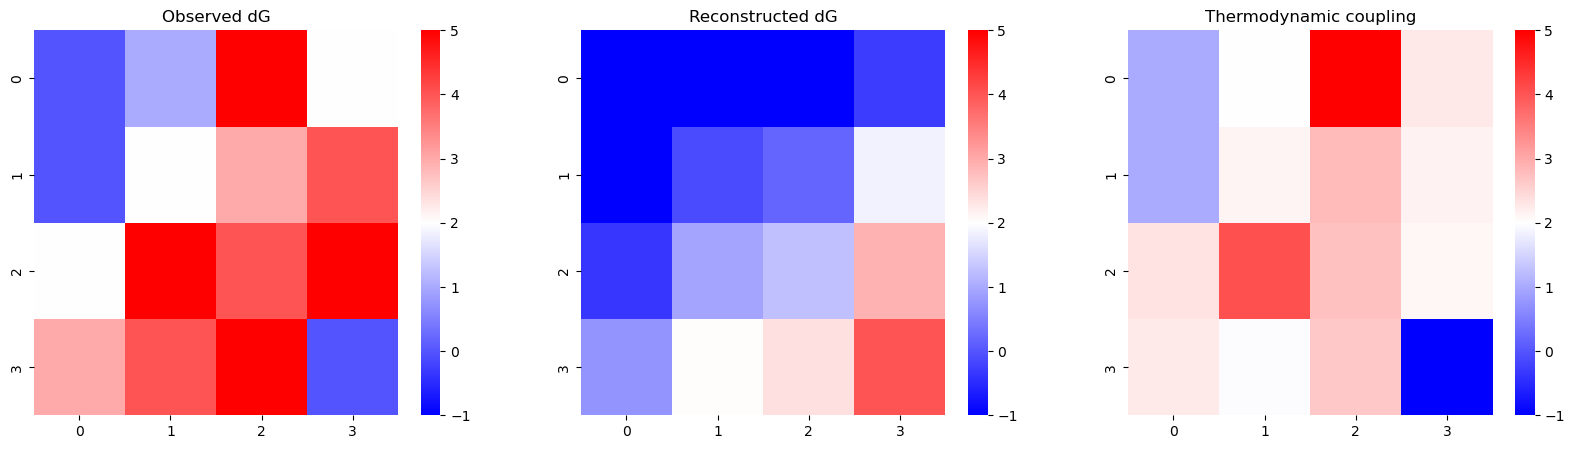

In [7]:
plt.figure(figsize=(20,5))
plt.subplot(131)
sns.heatmap(np.reshape(list(df_mock_data['dG']),(4,4)),cmap='bwr',vmin=-1,vmax=5)
plt.title('Observed dG')

plt.subplot(132)
sns.heatmap(np.reshape(list(df_mock_data['recon_dg']),(4,4)),cmap='bwr',vmin=-1,vmax=5)
plt.title('Reconstructed dG')

plt.subplot(133)
sns.heatmap(np.reshape(list(df_mock_data['thermodynamic_coupling']),(4,4)),cmap='bwr',vmin=-1,vmax=5)
plt.title('Thermodynamic coupling')

In [9]:
df_dmut = pd.read_csv('dG_for_double_mutants_Fig4.csv')
df_dmut

,aa1,aa2,dG,recon_dG,thermo_dynamics,dboule_mut_name
0,0,0,2.819273,2.915883,-0.096611,1A0N.pdb_hnet0
1,0,1,3.686627,3.333646,0.352980,1A0N.pdb_hnet0
2,0,2,4.985094,4.638069,0.347025,1A0N.pdb_hnet0
3,0,3,3.519796,3.377518,0.142278,1A0N.pdb_hnet0
4,0,4,4.004343,3.906331,0.098013,1A0N.pdb_hnet0
...,...,...,...,...,...,...
269511,19,15,2.455950,2.663696,-0.207746,HHH_rd4_0977.pdb_hnet0
269512,19,16,2.527644,2.381172,0.146472,HHH_rd4_0977.pdb_hnet0
269513,19,17,2.457718,2.469418,-0.011700,HHH_rd4_0977.pdb_hnet0
269514,19,18,2.448853,2.488740,-0.039887,HHH_rd4_0977.pdb_hnet0


In [10]:
aas='QENHDRKTSAGMCLVIWYFP' 

In [11]:
dmut_list = list(set(df_dmut['pair_name']))

df_sum = pd.DataFrame()

for dmut_name in dmut_list[:3]:

    sub_df = df_dmut[df_dmut['pair_name']==dmut_name]
    sub_df['aa1'] = [aas.index(x.split(':')[0][-1]) for x in sub_df['mut_type']]
    sub_df['aa2'] = [aas.index(x.split(':')[1][-1]) for x in sub_df['mut_type']]
    sub_df['dG'] = sub_df['deltaG']

    rng_key = random.PRNGKey(1)
    rng_key, rng_key_ = random.split(rng_key)

    kernel = NUTS(additive_model, init_strategy=initialization.init_to_feasible())
    mcmc = MCMC(kernel, num_warmup=100, num_samples=50, num_chains=1)


    mcmc.run(rng_key_,df_dg = sub_df,aa_len=20)
    samples_dg = mcmc.get_samples()

    first_aa_effect = np.median(samples_dg['first_aa_effect'],axis=0)
    second_aa_effect = np.median(samples_dg['second_aa_effect'],axis=0)

    sub_df['recon_dg'] = [first_aa_effect[aa1] + second_aa_effect[aa2] for aa1,aa2 in zip(sub_df['aa1'],sub_df['aa2'])]
    sub_df['thermodynamic_coupling'] = sub_df['dG'] - sub_df['recon_dg']
    df_sum = df_sum.append(sub_df)
df_sum

KeyError: 'pair_name'